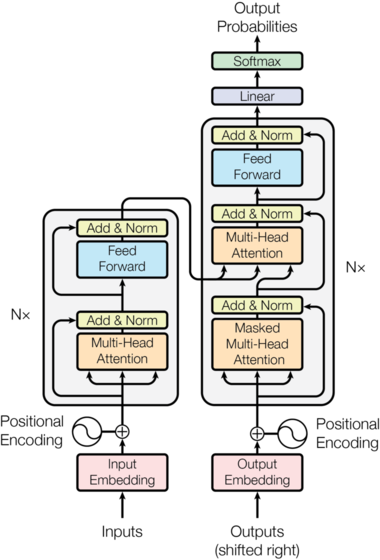

# Encoder

## 🧠 Encoder Overview

The **goal of the encoder** is to generate a rich embedding representation of the input text.  
This embedding:

- Captures **semantic information** about the input
- Is passed to the **decoder** to help generate the output text

The encoder is composed of a **stack of N layers**.

Before diving into those layers, we first need to understand **how the words (or tokens) are passed into the model**.

---

> ### 🔍 Note: What Are Embeddings?
> The term **"embedding"** is used *a lot* in this context:
>
> - We **initially create an embedding** for each input token — this goes into the encoder.
> - The **encoder outputs embeddings** (often called *hidden states*).
> - The **decoder also receives and uses embeddings** to generate predictions.
>
> 😅 In short: embeddings are just **vector representations of tokens** that carry meaning in a form the model can work with.


# 0. Tokenization

## 🔢 Tokenization: Turning Text into Numbers

Machine learning models can’t process raw text — they work with **numbers**.  
That’s where **tokenization** comes in!

---

### ✂️ What is Tokenization?

Tokenization is the process of **splitting input text into tokens**, each assigned a **numerical ID**.

For example:
- `"Hello World"` → tokens: `"Hello"`, `"World"`
- Or even → `"H"`, `"e"`, `"l"`, `"l"`, `"o"`, `" "`, `"W"`, `"o"`, `"r"`, `"l"`, `"d"`

The way we tokenize depends on the **goal and the language**.

---

### 📚 Types of Tokenization

#### 1. **Word-based Tokenization**
- Splits text into whole words
- Needs a **very large vocabulary**
- Doesn't generalize well (e.g., `"dog"` vs `"dogs"`, `"run"` vs `"running"` are separate tokens)

#### 2. **Character-based Tokenization**
- Splits text into individual characters
- **Smaller vocabulary**, but **less semantic meaning**
- Useful for languages like **Chinese**, where characters hold more meaning

#### 3. **Subword Tokenization** (Most popular today)
- A **hybrid** approach: breaks words into meaningful subunits  
- Example: `"tokenization"` → `"token"`, `"ization"`
- Uses statistical methods (like **Byte-Pair Encoding (BPE)** or **WordPiece**) to decide how to split
- It’s **deterministic**, not learned like model weights

---

### ✅ For This Notes

We’ll use **word-level tokenization** for simplicity.

**Example:**  
Input: `"Hello World"`  
Tokenized: `["Hello", "World"]`  
Vocabulary mapping:  
- `"Hello"` → Token ID `1`  
- `"World"` → Token ID `2`

This numerical sequence becomes the **input to the model**.


# 1. Embedding the text

## 🧬 Embeddings: Adding Meaning to Tokens

While we could feed raw token IDs (like `1` and `2`) into the model,  
these numbers don’t carry any **semantic meaning**.

That’s where **embeddings** come in!

---

### 🎯 What Is an Embedding?

An **embedding** maps each token ID to a **vector of fixed size** that captures semantic meaning.  
It allows the model to understand how tokens relate to each other.

> Similar tokens → Similar vectors  
> (measured using **cosine similarity**)

---

### 🧠 Learned Representations

- The mapping from token → vector is **learned during training**.
- While some models use **pre-trained embeddings** (like word2vec or GloVe),  
  **transformers learn embeddings as part of the training process**.

This allows the model to adapt to the specific task and dataset.

For example:
- `"dog"` and `"dogs"` → will get **similar embeddings**

---

### 📏 Embedding Size

All embeddings in a model have the **same dimensionality**.

- Original Transformer: `512` dimensions  
- Our example (for simplicity): `4` dimensions

---

### 🧪 Example

Let’s manually assign some example embeddings:

```text
"Hello" → [1, 2, 3, 4]  
"World" → [2, 3, 4, 5]


In [3]:
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embedding_hello = model.encode(["Hello"])[0]  # shape (384,)
embedding_world = model.encode(["World"])[0]  # shape (384,)

# Just take the first 4 dims (for demo only)
hello = embedding_hello[:4]
world = embedding_world[:4]

print(hello)
print(world)

[-0.06277172  0.05495879  0.05216483  0.08578998]
[-0.0302381   0.03164672 -0.06337421 -0.01367683]


# 2. Positional encoding

## 🛰️ Positional Encoding: Giving Order to Words

Token embeddings alone **do not carry any information about word order**.  
So we need to **inject positional information** into the model.

---

### 🧭 Why Positional Encoding?

Transformers are **position-agnostic** — they treat input tokens as a set, not a sequence.

To fix this, we **add a positional encoding vector** to each token’s embedding.  
This lets the model distinguish between tokens based on their position in the sequence.

---

### 📐 How Do We Encode Position?

There are two common approaches:

- **Learned** positional embeddings (e.g. used in BERT)
- **Fixed** sinusoidal positional encodings (used in the original Transformer paper)

> We’ll use the **fixed** version, following the original paper (Section 3.5),  
> because it's simpler and works just as well in many cases.

---

### 🌊 Sinusoidal Encoding Formula

We assign each position a unique vector using sine and cosine functions.

- Even indices → use **sine**
- Odd indices → use **cosine**

This gives a **wave-like structure** that helps the model learn about relative positions and patterns.

---

#### 📄 Formula from the Transformer paper:

$$
\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

$$
\text{PE}(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

---

### 🧮 Example Calculation (4D Embeddings)

Let’s calculate positional encodings for two tokens: `"Hello"` (position 0) and `"World"` (position 1).  
We'll use an embedding dimension of `d = 4`.

#### 🔹 For `"Hello"` at position `pos = 0`:

| Index `i` | Even/Odd | Formula                            | Value     |
|-----------|----------|-------------------------------------|-----------|
| 0         | Even     | `sin(0 / 10000^(0 / 4))`            | `0`       |
| 1         | Odd      | `cos(0 / 10000^(2 * 1 / 4))`        | `1`       |
| 2         | Even     | `sin(0 / 10000^(2 * 2 / 4))`        | `0`       |
| 3         | Odd      | `cos(0 / 10000^(2 * 3 / 4))`        | `1`       |

Result:
```text
"Hello" → [0, 1, 0, 1]
````

#### 🔹 For `"World"` at position `pos = 1`:

| Index `i` | Even/Odd | Formula                      | Approx. Value |
| --------- | -------- | ---------------------------- | ------------- |
| 0         | Even     | `sin(1 / 10000^(0 / 4))`     | ≈ 0.84        |
| 1         | Odd      | `cos(1 / 10000^(2 * 1 / 4))` | ≈ 0.99        |
| 2         | Even     | `sin(1 / 10000^(2 * 2 / 4))` | ≈ 0           |
| 3         | Odd      | `cos(1 / 10000^(2 * 3 / 4))` | ≈ 1           |

Result:

```text
"World" → [0.84, 0.99, 0, 1]
```

---

### ➕ Final Input Representation

We **add** the positional encoding vector to the token embedding vector:

```
Final Representation = Token Embedding + Positional Encoding
```

> This ensures both **semantic meaning** and **positional context** are included.

---

> 📝 **Note:**
> While we’re using sine and cosine like the original paper, many modern models like **BERT** use **trainable** positional embeddings instead.

# 3. Add positional encoding and embedding

## ➕ Adding Positional Encoding to Embeddings

Now that we have both the **token embeddings** and the **positional encodings**,  
we simply **add them together** (element-wise) to produce the final input to the encoder.


### 📥 Example

#### "Hello":
- Embedding: `[1, 2, 3, 4]`
- Positional Encoding: `[0, 1, 0, 1]`

```text
"Hello" = [1, 2, 3, 4] + [0, 1, 0, 1] = [1, 3, 3, 5]
````

#### "World":

* Embedding: `[2, 3, 4, 5]`
* Positional Encoding: `[0.84, 0.99, 0, 1]`

```text
"World" = [2, 3, 4, 5] + [0.84, 0.99, 0, 1] = [2.84, 3.99, 4, 6]
```

---

### 🧱 Final Input Matrix to the Encoder

```text
[[1.00, 3.00, 3.00, 5.00],    ← "Hello"
 [2.84, 3.99, 4.00, 6.00]]    ← "World"
```

This matrix becomes the **input to the encoder** — it's a combination of:

* **Semantic meaning** from the embeddings
* **Positional structure** from the encoding

---

> 🖼️ If you refer back to the original Transformer paper diagram,
> this corresponds to the **bottom-left part**:
> `Embedding` + `Positional Encoding` = `Input to Encoder`

In [4]:
def positional_encoding(pos, d_model=4):
    PE = np.zeros(d_model)
    for i in range(0, d_model, 2):
        denom = np.power(10000, 2 * i / d_model)
        PE[i]   = np.sin(pos / denom)
        PE[i+1] = np.cos(pos / denom)
    return PE

# Position encodings for position 0 and 1
pe0 = positional_encoding(0, d_model=4)
pe1 = positional_encoding(1, d_model=4)

print("PE(0):", pe0)
print("PE(1):", pe1)

PE(0): [0. 1. 0. 1.]
PE(1): [8.41470985e-01 5.40302306e-01 9.99999998e-05 9.99999995e-01]


In [5]:
x0_pe = hello + pe0
x1_pe = world + pe1

print("Positionally encoded x0:", x0_pe)
print("Positionally encoded x1:", x1_pe)


Positionally encoded x0: [-0.06277172  1.05495879  0.05216483  1.08578998]
Positionally encoded x1: [ 0.81123288  0.57194903 -0.06327421  0.98632317]


# 4. Self-attention

## 4.1 Matrices Definition: Multi-Head Attention

Attention is a mechanism that allows a model to **focus on certain parts of the input**.  
Multi-head attention extends this idea by allowing the model to **jointly attend to information from different representation subspaces** at different positions.

---

### What is Multi-Head Attention?

- Instead of having a single set of key (K), value (V), and query (Q) matrices, multi-head attention uses **multiple attention heads**.
- Each head has its own K, V, Q matrices.
- This enables the model to capture different types of relationships and features from the input.

---

### Example Setup

- We'll use **2 attention heads** for this example.
- Each matrix (`K`, `V`, `Q`) is a **4×3 matrix**.
- The input embedding dimension is 4.
- The attention dimension (key, value, query space) is reduced to 3.
- This dimensionality reduction helps control computational complexity.
- *Note:* Using too small an attention dimension can degrade model performance.

---

Each attention head computes attention independently, and their outputs are later concatenated or combined to form the final result.


## 4.2 Keys, queries, and values calculation

In [6]:
def he_init(shape):
    fan_in = shape[1]  # number of input neurons (columns)
    std = np.sqrt(2. / fan_in)
    return np.random.normal(0, std, size=shape)
    
WK1 = he_init((4, 3))
WV1 = he_init((4, 3))
WQ1 = he_init((4, 3))

WK2 = he_init((4, 3))
WV2 = he_init((4, 3))
WQ2 = he_init((4, 3))

print("WK1:\n", WK1)
print("WV1:\n", WV1)
print("WQ1:\n", WQ1)


WK1:
 [[-0.80957717 -0.66634086 -0.46035735]
 [-0.75419912  0.23685321  0.45409237]
 [-0.16949486 -0.24929574  0.0468191 ]
 [ 0.76373682  0.77909418 -0.54365235]]
WV1:
 [[ 0.78010375 -0.22363582  0.75449292]
 [ 0.22359853 -0.32234715  0.18465782]
 [ 0.81556088 -0.59250924 -0.47103787]
 [ 1.33497727 -1.18869141  0.54461214]]
WQ1:
 [[-1.28477827 -0.75113407 -1.18852542]
 [ 0.00191822  1.0235744  -0.13717589]
 [-0.60650102  0.00729152 -1.16951211]
 [ 0.09165656 -1.10872799  0.60325244]]


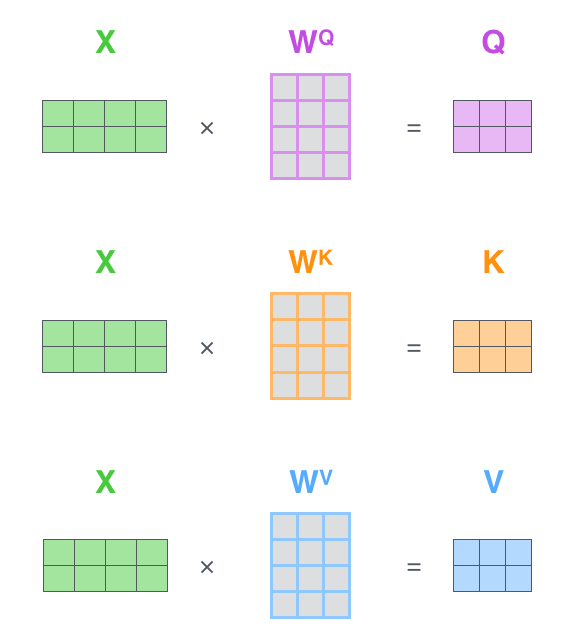

### Key Calculation

In [7]:
# embedding = np.array([
#     [1, 3, 3, 5], # hello (emd + pe)
#     [2.84, 3.99, 4, 6] # world (emd + pe)
# ])
embedding = np.vstack([x0_pe, x1_pe])
K1 = embedding @ WK1
print(K1)

[[ 0.07558567  1.12462593 -0.07990381]
 [-0.3241031   0.37912298 -0.65291868]]


### Value Calculation

In [8]:
V1 = embedding @ WV1
print(V1)

[[ 1.67896732 -1.64760233  0.71420836]
 [ 2.02584781 -1.5007302   1.28465245]]


### Query calculation

In [9]:
Q1 = embedding @ WQ1
print(Q1)

[[ 0.15055313 -0.07648659  0.52388893]
 [-0.9123784  -1.11793775 -0.3736267 ]]


- We will back to Second Head later

## 4.3 Attention calculation

### Calculating the Attention Score

To compute the attention scores, we perform the following steps:

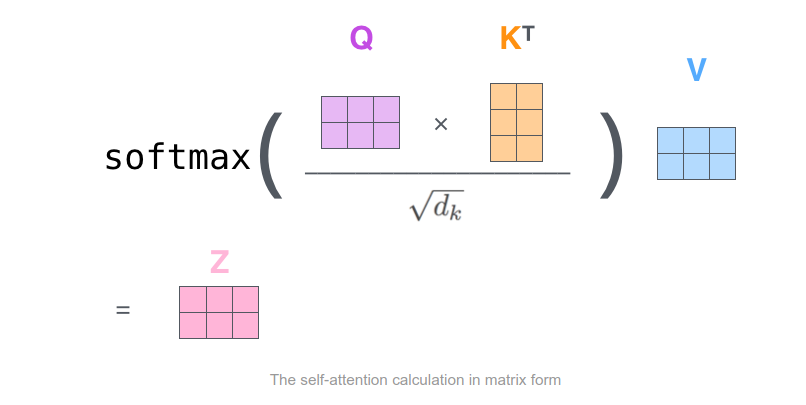

#### Step 1: Dot Product of Query with Keys

- For each query vector \(Q\), calculate the dot product with all key vectors \(K\).  
- This measures the similarity between the query and each key.

$$
\text{scores} = Q \cdot K^T
$$

---

#### Step 2: Scale the Scores

- Divide each score by the square root of the key dimension \(d_k\) to prevent large values that could push softmax into regions with very small gradients.

$$
\text{scaled\_scores} = \frac{\text{scores}}{\sqrt{d_k}}
$$

---

#### Step 3: Apply Softmax

- Apply the softmax function to the scaled scores to obtain attention weights.  
- This converts scores into probabilities that sum to 1.

$$
\text{attention\_weights} = \text{softmax}(\text{scaled\_scores})
$$

---

#### Step 4: Weighted Sum of Value Vectors

- Multiply each value vector \(V\) by the corresponding attention weight.  
- Sum these weighted vectors to get the final output of the attention mechanism.

$$
\text{output} = \sum_i \text{attention\_weights}_i \times V_i
$$

---

#### Summary Formula

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V
$$

---

This process enables the model to selectively focus on relevant parts of the input based on the query.


#### 4.3.1 Dot product of query with each key

In [10]:
scores_1 = Q1 @ K1.T
print(scores_1)

[[-0.11649986 -0.41984943]
 [-1.29637031  0.11581663]]


#### 4.3.2 Divide by square root of dimension of key vector

##### Why Scale the Dot-Product Scores?

After computing the dot product between the query and key vectors, we divide the scores by the square root of the key dimension \( d \). 

For example, if \( d = 3 \) (in our simple example) or \( d = 64 \) (in the original Transformer paper), the reason is:

- The dot product tends to grow large as \( d \) increases, because it sums over \( d \) multiplied terms.
- Large values cause the softmax function to push most attention weights towards very small values except a few, leading to **vanishing gradients** during training.
- Scaling by $( \frac{1}{\sqrt{d}})$ keeps the values in a more manageable range, improving training stability and effectiveness.

In short: **Scaling prevents extremely large values in the dot product, which helps the softmax function behave better.**


In [11]:
scores_1 = scores_1 / np.sqrt(3) # dim of keys is 3
print(scores_1)

[[-0.06726123 -0.24240018]
 [-0.74845975  0.06686676]]


#### 4.3.3 Apply softmax function

##### Applying Softmax to Normalize Scores

After scaling the dot-product scores, we apply the **softmax** function to convert them into probabilities. This ensures:

- All attention weights are **positive**.
- All attention weights **sum to 1**.

---

##### What is Softmax?

Softmax takes a vector of values 

$$
\mathbf{z} = [z_1, z_2, \ldots, z_n]
$$

and outputs a vector 

$$
\sigma(\mathbf{z}) = [\sigma(\mathbf{z})_1, \sigma(\mathbf{z})_2, \ldots, \sigma(\mathbf{z})_n]
$$

where each element is between 0 and 1 and the sum is 1:

$$
\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^n e^{z_j}}
$$

---

##### Example

Suppose we have the vector:

$$
\mathbf{z} = [1.0, 2.0, 0.5]
$$

Step 1: Compute the exponentials of each element:

$$
e^{1.0} = 2.718, \quad e^{2.0} = 7.389, \quad e^{0.5} = 1.649
$$

Step 2: Sum the exponentials:

$$
2.718 + 7.389 + 1.649 = 11.756
$$

Step 3: Calculate the softmax values:

$$
\sigma(\mathbf{z}) = \left[ \frac{2.718}{11.756}, \frac{7.389}{11.756}, \frac{1.649}{11.756} \right] \approx [0.231, 0.628, 0.140]
$$

---

As you can see, all the values are positive and sum to 1:

$$
0.231 + 0.628 + 0.140 = 0.999 \approx 1
$$

This makes softmax perfect for converting raw scores into attention weights!


In [12]:
def softmax(x):
    # Subtract max per row for numerical stability
    x_max = np.max(x, axis=1, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=1, keepdims=True)

scores_1 = softmax(scores_1)
scores_1

array([[0.54367316, 0.45632684],
       [0.30675661, 0.69324339]])

#### 4.3.4 Multiply value matrix by attention weights

In [13]:
attention_1 = scores_1 @ V1
print(attention_1)

[[ 1.8372582  -1.58058063  0.97451731]
 [ 1.91943993 -1.54578419  1.10966495]]


##### Combining All Steps into the Attention Formula

Let's combine steps 4.3.1, 4.3.2, 4.3.3, and 4.3.4 into a single formula using matrices (from section 3.2.1 of the original Transformer paper):

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V
$$

Yes, that’s it! All the math we just did can easily be encapsulated in the attention formula above.

In [14]:
def attention(x, WQ, WK, WV):
    K = x @ WK
    V = x @ WV
    Q = x @ WQ

    scores = Q @ K.T
    scores = scores / np.sqrt(3)
    scores = softmax(scores)
    scores = scores @ V
    return scores

In [15]:
attention(embedding, WQ1, WK1, WV1)

array([[ 1.8372582 , -1.58058063,  0.97451731],
       [ 1.91943993, -1.54578419,  1.10966495]])

In [16]:
attention_1 = attention(embedding, WQ1, WK1, WV1)
attention_1

array([[ 1.8372582 , -1.58058063,  0.97451731],
       [ 1.91943993, -1.54578419,  1.10966495]])

In [17]:
attention_2 = attention(embedding, WQ2, WK2, WV2)
attention_2

array([[ 0.98526797, -0.02158939, -0.30583422],
       [ 1.06630545,  0.02138475, -0.31919903]])

In [18]:
softmax(((embedding @ WQ2) @ (embedding @ WK2).T) / np.sqrt(3))

array([[0.45913953, 0.54086047],
       [0.41455254, 0.58544746]])

#### 4.3.5 Heads’ attention output

##### Concatenating Multiple Attention Heads

The next layer of the encoder expects a **single matrix** as input, not multiple separate outputs.

Therefore, after computing the outputs from the two (or more) attention heads, we **concatenate** their outputs along the feature dimension.

This step is described in section 3.2.2 of the original paper.

If each head’s output has shape:

$$
\text{head}_i \in \mathbb{R}^{\text{seq\_len} \times d_v}
$$

and there are \(h\) heads, the concatenated output is:

$$
\text{Concat}(\text{head}_1, \text{head}_2, \ldots, \text{head}_h) \in \mathbb{R}^{\text{seq\_len} \times (h \cdot d_v)}
$$

This concatenated matrix will then be passed to the next encoder layer.

In [19]:
attentions = np.concatenate([attention_1, attention_2], axis=1)
attentions

array([[ 1.8372582 , -1.58058063,  0.97451731,  0.98526797, -0.02158939,
        -0.30583422],
       [ 1.91943993, -1.54578419,  1.10966495,  1.06630545,  0.02138475,
        -0.31919903]])

- We finally multiply this concatenated matrix by a weight matrix to obtain the final output of the attention layer. This weight matrix is also learned! The dimension of the matrix ensures we go back to the same dimension as the embedding (4 in our case).

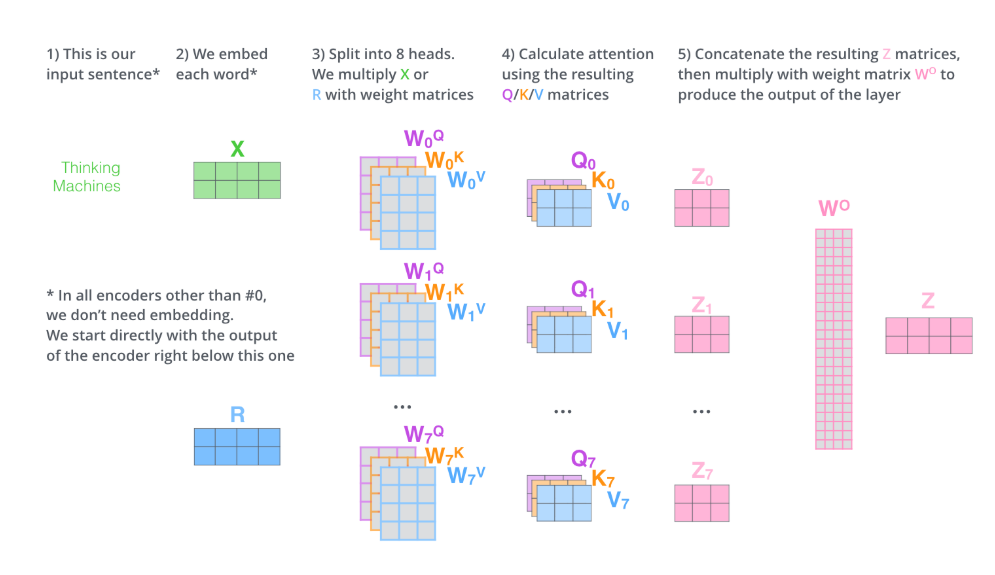

In [20]:
# Just some random values
W = np.array(
    [
        [0.79445237, 0.1081456, 0.27411536, 0.78394531],
        [0.29081936, -0.36187258, -0.32312791, -0.48530339],
        [-0.36702934, -0.76471963, -0.88058366, -1.73713022],
        [-0.02305587, -0.64315981, -0.68306653, -1.25393866],
        [0.29077448, -0.04121674, 0.01509932, 0.13149906],
        [0.57451867, -0.08895355, 0.02190485, 0.24535932],
    ]
)
Z = attentions @ W
Z

array([[ 0.43757291, -0.58016221, -0.52382242, -0.79883624],
       [ 0.46632777, -0.73991901, -0.68654552, -1.0853103 ]])

# 5. Feed-forward layer

### 5.1 Basic Feed-Forward Layer

After the self-attention layer, the encoder has a feed-forward neural network (FFN). This is a simple network with two linear transformations and a ReLU activation in between.

The goal of the FFN is to process and transform the representation produced by the attention mechanism.

The flow is usually as follows (see section 3.3 of the original paper):

1. **First linear layer:**  
   This usually expands the dimensionality of the input. For example, if the input dimension is 512, the output dimension might be 2048. This allows the model to learn more complex functions.  
   In our simple example with input dimension 4, we’ll expand to 8.

2. **ReLU activation:**  
   This is a non-linear activation function. It returns 0 if the input is negative, and the input itself if positive.  
   The math is:

   $$
   \text{ReLU}(x) = \max(0, x)
   $$

3. **Second linear layer:**  
   This reduces the dimensionality back to the original dimension. In our example, from 8 back to 4.

---

We can represent all of this as:

$$
\text{FFN}(Z) = \max(0, Z W_1 + b_1) W_2 + b_2
$$

where:

- $( Z )$ is the input matrix (from self-attention output),
- $( W_1 )$ and \( W_2 \) are weight matrices for the two linear layers,
- $( b_1 )$ and \( b_2 \) are bias vectors,
- $(\max(0, \cdot))$ is the element-wise ReLU function.

---

Just as a reminder, the input for this layer is the \( Z \) we calculated in the self-attention above. Here are the values as a reminder:


In [21]:
# Shapes
W1_shape = (4, 8)  # fan_in = 4
W2_shape = (8, 4)  # fan_in = 8

# He initialization for weights
W1 = np.random.randn(*W1_shape) * np.sqrt(2. / W1_shape[0])
W2 = np.random.randn(*W2_shape) * np.sqrt(2. / W2_shape[0])

# Bias initialization (zero or small random)
b1 = np.zeros(W1_shape[1])  # shape (8,)
b2 = np.zeros(W2_shape[1])  # shape (4,)

In [22]:
def relu(x):
    return np.maximum(0, x)

In [23]:
def feed_forward(Z, W1, b1, W2, b2):
    return relu(Z.dot(W1) + b1).dot(W2) + b2

In [24]:
output_encoder = feed_forward(Z, W1, b1, W2, b2)
output_encoder

array([[-0.50589016, -1.58682813,  0.14602844, -0.48604913],
       [-0.76074949, -2.2186713 ,  0.21205467, -0.66198028]])

### 5.2 Encapsulating everything: The Random Encode

In [25]:
# Dimensions
d_embedding = 4
d_key = d_value = d_query = 3
d_feed_forward = 8
n_attention_heads = 2

# --- Utility Functions ---

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)  # for numerical stability
    e_x = np.exp(x)
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

def he_init(shape):
    fan_in = shape[0]
    return np.random.randn(*shape) * np.sqrt(2. / fan_in)

# --- Core Components ---

def attention(x, WQ, WK, WV):
    Q = x @ WQ
    K = x @ WK
    V = x @ WV

    scores = Q @ K.T
    scores /= np.sqrt(d_key)
    weights = softmax(scores)
    return weights @ V  # shape: (seq_len, d_value)

def multi_head_attention(x, WQs, WKs, WVs):
    heads = [
        attention(x, WQ, WK, WV)
        for WQ, WK, WV in zip(WQs, WKs, WVs)
    ]
    concatenated = np.concatenate(heads, axis=-1)  # shape: (seq_len, n_heads * d_value)

    # Output projection back to d_embedding
    W_out = he_init((n_attention_heads * d_value, d_embedding))
    return concatenated @ W_out  # shape: (seq_len, d_embedding)

def feed_forward(Z, W1, b1, W2, b2):
    return relu(Z @ W1 + b1) @ W2 + b2

def encoder_block(x, WQs, WKs, WVs, W1, b1, W2, b2):
    Z = multi_head_attention(x, WQs, WKs, WVs)
    Z = feed_forward(Z, W1, b1, W2, b2)
    return Z

# --- Randomized Encoder Block ---

def random_encoder_block(x):
    WQs = [he_init((d_embedding, d_query)) for _ in range(n_attention_heads)]
    WKs = [he_init((d_embedding, d_key)) for _ in range(n_attention_heads)]
    WVs = [he_init((d_embedding, d_value)) for _ in range(n_attention_heads)]

    W1 = he_init((d_embedding, d_feed_forward))
    b1 = np.zeros(d_feed_forward)
    W2 = he_init((d_feed_forward, d_embedding))
    b2 = np.zeros(d_embedding)

    return encoder_block(x, WQs, WKs, WVs, W1, b1, W2, b2)

In [26]:
embedding

array([[-0.06277172,  1.05495879,  0.05216483,  1.08578998],
       [ 0.81123288,  0.57194903, -0.06327421,  0.98632317]])

In [27]:
random_encoder_block(embedding)

array([[ 0.54845622,  0.78906586,  1.01871542, -0.28046382],
       [ 0.56438487,  0.69450464,  0.95389499, -0.36093051]])

- This was just one encoder block. The original paper uses 6 encoders. The output of one encoder goes to the next, and so on:

In [28]:
def encoder(x, n=6):
    for _ in range(n):
        x = random_encoder_block(x)
    return x

In [29]:
encoder(embedding)

array([[ 65.96956552,  62.39386821,   0.13534639, -94.67861808],
       [ 65.96956552,  62.39386821,   0.13534639, -94.67861808]])

## 5.3 Residual and Layer Normalization

To improve training and gradient flow, the Transformer architecture applies two important techniques (section 3.1 of the paper):

---

### ✅ Residual Connections

**Residual connections** add the input of a layer to its output. For example, we add the initial embedding to the output of the attention.

Residual connections help mitigate the **vanishing gradient** problem.

The math is very simple:

$$
\text{Output} = \text{Layer}(x) + x
$$

That’s it! We apply this after:

- The self-attention block
- The feed-forward network (FFN)

---

### ✅ Layer Normalization

**Layer normalization** normalizes across the **embedding dimension** of a single input (not across the batch). The goal is to stabilize and speed up training by ensuring inputs to each layer have zero mean and unit variance.

The equation is:

$$
\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

Where:

- $( \mu )$ is the **mean** of the embedding vector \(x\)
- $( \sigma^2 )$ is the **variance** of the embedding vector \(x\)
- $( \epsilon )$ is a small constant to prevent division by zero
- $( \gamma )$ and $( \beta )$ are **learnable parameters** for scaling and shifting

> 🔎 Unlike **batch normalization**, layer normalization operates **independently for each example** and only across the embedding dimension.

Why do we include $( \gamma )$ and $( \beta )$?  
Because if we only normalize, we could limit the representational capacity. Learnable parameters allow the model to **reintroduce scale and bias** if needed.

---

### 🧮 Putting It All Together

Each sub-layer (attention, FFN) in the encoder is wrapped with residual connection and layer normalization.

The formula for a single sub-layer block looks like:

$$
\text{LayerNorm}(x + \text{Sublayer}(x))
$$

---

### Let’s Try an Example

We’ll use the output from self-attention, denoted as \( Z \), and the original input embedding \( E \).

Now we calculate the layer normalization in **three steps**:

---

### Step 1: Compute Mean and Variance

For the first embedding vector:

$$
x = [x_1, x_2, \ldots, x_d]
$$

Compute the mean:

$$
\mu = \frac{1}{d} \sum_{i=1}^{d} x_i
$$

Compute the variance:

$$
\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2
$$

---

### Step 2: Normalize

Apply the normalization:

$$
\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

---

### Step 3: Scale and Shift

Multiply by $( \gamma )$, add $( \beta )$:

$$
\text{LayerNorm}(x)_i = \gamma \cdot \hat{x}_i + \beta
$$

---

You would repeat this process for each embedding (e.g., the second row of your matrix).  
We’ll skip the actual numbers here — but you get the idea.

### Transformer Encoder Architecture

Combining the equations, the equation for the whole encoder could look like this:

**Self-Attention with Residual Connection:**
$$Z(x) = \text{LayerNorm}(x + \text{Attention}(x))$$

**Feed-Forward Network:**
$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

**Complete Encoder Block:**
$$\text{Encoder} = \text{LayerNorm}(Z(x) + \text{FFN}(Z(x) + x))$$

### 5.3.1 Mean and variance

In [30]:
(embedding + Z).mean(axis=-1, keepdims=True)

array([[0.16622348],
       [0.06519595]])

In [31]:
(embedding + Z).std(axis=-1, keepdims=True)

array([[0.37422923],
       [0.74421119]])

### 5.3.2 Normalize

In [32]:
def layer_norm(x, epsilon=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + epsilon)

def encoder_block(x, WQs, WKs, WVs, W1, b1, W2, b2):
    # Multi-head attention with residual + layer norm
    attn_output = multi_head_attention(x, WQs, WKs, WVs)
    Z = layer_norm(attn_output + x)

    # Feed-forward with residual + layer norm
    ff_output = feed_forward(Z, W1, b1, W2, b2)
    return layer_norm(ff_output + Z)

In [33]:
layer_norm(Z + embedding)

array([[ 0.55735131,  0.82455418, -1.70451507,  0.32260957],
       [ 1.62905784, -0.31330572, -1.09513886, -0.22061327]])

In [34]:
def encoder(x, n=6):
    for _ in range(n):
        x = random_encoder_block(x)
    return x


encoder(embedding)

array([[-1.63233501,  0.04229641,  0.60850244,  0.98153616],
       [-1.69079965,  0.26727423,  0.54361908,  0.87990633]])

# Decoder

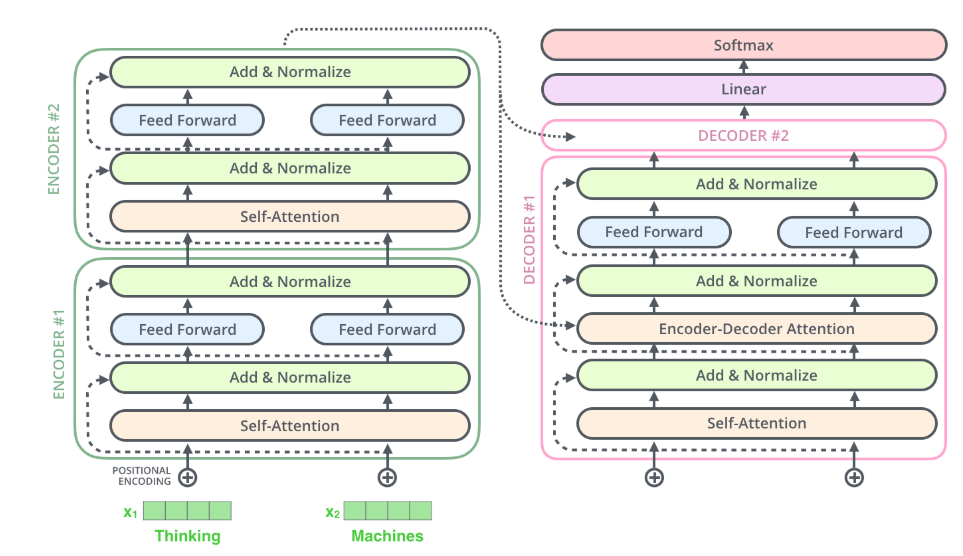

Most of the concepts we learned for encoders apply to the decoder as well! The decoder has two attention layers: one for self-attention and one for encoder-decoder attention. The decoder also includes a feed-forward layer. Let's examine each component in detail.

## Decoder Inputs and Operation

The decoder block receives two inputs: the output of the encoder and the generated output sequence. The encoder output provides the representation of the input sequence. During inference, the generated output sequence starts with a special start-of-sequence token (SOS). During training, the target output sequence is the actual output sequence, shifted by one position.

Given the embedding generated by the encoder and the SOS token, the decoder generates the next token in the sequence, such as "hola". The decoder operates autoregressively, meaning it uses previously generated tokens to produce the next token in the sequence.

## Autoregressive Generation Process

The generation process works as follows:

- **Iteration 1:** Input is SOS → Output is "hola"
- **Iteration 2:** Input is SOS + "hola" → Output is "mundo"  
- **Iteration 3:** Input is SOS + "hola" + "mundo" → Output is EOS

Here, SOS represents the start-of-sequence token and EOS represents the end-of-sequence token. The decoder stops generation when it produces the EOS token, generating one token at a time. Note that all iterations utilize the same embedding generated by the encoder.

> **Important Note:** This autoregressive design makes the decoder inherently slow. The encoder can generate its embedding in a single forward pass, while the decoder requires multiple forward passes. This is why encoder-only architectures (such as BERT or sentence similarity models) are significantly faster than decoder-only architectures (such as GPT-2 or BART).

## Decoder Block Structure

Like the encoder, the decoder consists of a stack of decoder blocks. However, the decoder block is more complex than its encoder counterpart. The general structure includes:

1. **Masked Self-attention layer**
2. **Residual connection and layer normalization**
3. **Encoder-decoder attention layer**
4. **Residual connection and layer normalization**
5. **Feed-forward layer**
6. **Residual connection and layer normalization**

This architecture allows the decoder to attend to both its own sequence (through masked self-attention) and the encoder's output (through encoder-decoder attention), enabling effective sequence-to-sequence transformation.

# 1. Embedding the text

### Decoder Step 1: Embed the Input Token

The first step of the decoder is to **embed the input tokens**.

In this case, the input token is `<SOS>` (Start of Sequence), so we'll embed it.

We’ll use the **same embedding dimension** as the encoder.

Let’s assume the embedding vector for `<SOS>` is the following:
$$
\text{Embed}(\text{<SOS>}) = \begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}
$$
> 📌 This vector will be used as the initial input to the decoder's first time step.


# 2. Positional encoding

### Decoder Step 2: Add Positional Encoding

We’ll now **add the positional encoding** to the embedding, just as we did for the encoder.

Given it’s the same position as “Hello”, we’ll use the same positional encoding values:

Let:

- $i$ = dimension index
- $pos = 0$ (first word)

Then:

- For $i = 0$ (even):

  $$
  PE(0, 0) = \sin\left( \frac{0}{10000^{\frac{0}{4}}} \right) = \sin(0) = 0
  $$

- For $i = 1$ (odd):

  $$
  PE(0, 1) = \cos\left( \frac{0}{10000^{\frac{2 \cdot 1}{4}}} \right) = \cos(0) = 1
  $$

- For $i = 2$ (even):

  $$
  PE(0, 2) = \sin\left( \frac{0}{10000^{\frac{2 \cdot 2}{4}}} \right) = \sin(0) = 0
  $$

- For $i = 3$ (odd):

  $$
  PE(0, 3) = \cos\left( \frac{0}{10000^{\frac{2 \cdot 3}{4}}} \right) = \cos(0) = 1
  $$


# 3. Add positional encoding and embedding

Adding the positional encoding to the embedding is done by adding the two vectors together:
$$
\text{E} = \begin{bmatrix} 1 \\ 1 \\ 0 \\ 1 \end{bmatrix}
$$

# 4. Self-attention

In [35]:
d_embedding = 4
n_attention_heads = 2

embed = np.array([[1.0, 0, 0.0, 0]])  # shape (1, 4), for <sos>
pe = positional_encoding(0, d_model=4).reshape(1, -1)

E = embed + pe  # positionally encoded input

WQs = [np.random.randn(d_embedding, d_query) for _ in range(n_attention_heads)]
WKs = [np.random.randn(d_embedding, d_key) for _ in range(n_attention_heads)]
WVs = [np.random.randn(d_embedding, d_value) for _ in range(n_attention_heads)]

Z_self_attention = multi_head_attention(E, WQs, WKs, WVs)
Z_self_attention

array([[-1.73641285,  1.41395435,  1.30735579, -1.51287377]])

### Decoder Training vs Inference

Things are quite simple during **inference**.

But during **training**, things become a bit more tricky.

---

#### 🔹 Training Setup

During training, we typically use **unlabeled text data**, often scraped from the web.

- The **encoder's** job is to capture all the information from the input sequence.
- The **decoder's** job is to predict the **most likely next token** in the output sequence.

This means that the decoder **can only use the tokens that have been generated so far** — it **cannot look ahead** at future tokens.

---

#### 🔹 Why Masked Self-Attention?

To prevent the decoder from "cheating" by looking at future tokens, we use **masked self-attention**.

This is done by **masking** the positions of the attention matrix that correspond to future tokens:

- These positions are set to $-\infty$ before applying the softmax.
- As a result, the softmax assigns **zero probability** to those positions.

> 📌 This mechanism is described in the original Transformer paper (Section 3.2.3.1).

We’ll skip the implementation of masking for now, but it’s important to keep in mind:

> ✅ The decoder is more complex during training due to **auto-regressive masking**.


In [36]:
def attention(x, WQ, WK, WV):
    Q = x @ WQ
    K = x @ WK
    V = x @ WV

    T = x.shape[0]
    scores = Q @ K.T / np.sqrt(K.shape[-1])  # shape (T, T)

    # Decoder-style causal mask: prevent attending to future positions
    mask = np.triu(np.ones((T, T)), k=1)
    scores = scores - 1e9 * mask  # masked scores become large negative

    weights = softmax(scores)  # shape (T, T)
    return weights @ V  # shape (T, d_value)

def multi_head_attention(x, WQs, WKs, WVs):
    n_attention_heads = len(WQs)
    d_value = WVs[0].shape[1]
    d_embedding = x.shape[1]

    heads = [
        attention(x, WQ, WK, WV)
        for WQ, WK, WV in zip(WQs, WKs, WVs)
    ]
    concatenated = np.concatenate(heads, axis=-1)  # shape: (T, n_heads * d_value)

    # Output projection back to d_embedding
    W_out = he_init((n_attention_heads * d_value, d_embedding))
    return concatenated @ W_out  # shape: (T, d_embedding)

In [37]:
d_embedding = 4
n_attention_heads = 2

embed = np.array([[1.0, 0, 0.0, 0]])  # shape (1, 4), for <sos>
pe = positional_encoding(0, d_model=4).reshape(1, -1)

E = embed + pe  # positionally encoded input

WQs = [np.random.randn(d_embedding, d_query) for _ in range(n_attention_heads)]
WKs = [np.random.randn(d_embedding, d_key) for _ in range(n_attention_heads)]
WVs = [np.random.randn(d_embedding, d_value) for _ in range(n_attention_heads)]

Z_self_attention = multi_head_attention(E, WQs, WKs, WVs)
Z_self_attention

array([[0.91423991, 0.75632268, 2.39401073, 3.66769732]])

# 5. Residual connection and layer normalization

In [38]:
Z_self_attention = layer_norm(Z_self_attention + E)
Z_self_attention

array([[-0.65731761, -0.79233066, -0.24713235,  1.69678061]])

# 6. Encoder-decoder attention

### Encoder-Decoder Attention: The New Part!

This part is **the new one!**

If you were wondering **where the encoder-generated embeddings come in**, this is their moment to shine!

---

Let’s assume the output of the encoder is the following matrix:

$$
\mathbf{E} = 
\begin{bmatrix}
e_{11} & e_{12} & \cdots & e_{1d} \\
e_{21} & e_{22} & \cdots & e_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
e_{n1} & e_{n2} & \cdots & e_{nd}
\end{bmatrix}
$$

where $n$ is the sequence length and $d$ is the embedding dimension.

---

In the **self-attention mechanism**, we calculate the queries $\mathbf{Q}$, keys $\mathbf{K}$, and values $\mathbf{V}$ from the input embeddings $\mathbf{X}$:

$$
\mathbf{Q} = \mathbf{X} \mathbf{W}_Q, \quad
\mathbf{K} = \mathbf{X} \mathbf{W}_K, \quad
\mathbf{V} = \mathbf{X} \mathbf{W}_V
$$

---

In the **encoder-decoder attention**, however, the queries come from the previous decoder layer's output $\mathbf{D}$, while keys and values come from the encoder output $\mathbf{E}$:

$$
\mathbf{Q} = \mathbf{D} \mathbf{W}_Q, \quad
\mathbf{K} = \mathbf{E} \mathbf{W}_K, \quad
\mathbf{V} = \mathbf{E} \mathbf{W}_V
$$

---

All the math is the same as before; the only difference is **which embeddings we use for the queries**.


In [39]:
def encoder_decoder_attention(encoder_output, attention_input, WQ, WK, WV):
    K = encoder_output @ WK
    V = encoder_output @ WV
    Q = attention_input @ WQ

    scores = Q @ K.T
    scores /= np.sqrt(d_key)
    weights = softmax(scores)
    return weights @ V

def multi_head_encoder_decoder_attention(encoder_output, attention_input, WQs, WKs, WVs):
    heads = [
        encoder_decoder_attention(encoder_output, attention_input, WQ, WK, WV)
        for WQ, WK, WV in zip(WQs, WKs, WVs)
    ]
    concatenated = np.concatenate(heads, axis=1)  # concat on feature dim

    # He initialization for projection matrix W
    W = np.random.randn(n_attention_heads * d_value, d_embedding) * np.sqrt(2 / (n_attention_heads * d_value))
    return concatenated @ W

In [40]:
WQs = [np.random.randn(d_embedding, d_query) for _ in range(n_attention_heads)]
WKs = [np.random.randn(d_embedding, d_key) for _ in range(n_attention_heads)]
WVs = [np.random.randn(d_embedding, d_value) for _ in range(n_attention_heads)]

encoder_output = np.array([[-1.5, 1.0, -0.8, 1.5], [1.0, -1.0, -0.5, 1.0]])

Z_encoder_decoder = multi_head_encoder_decoder_attention(
    encoder_output, Z_self_attention, WQs, WKs, WVs
)
Z_encoder_decoder

array([[-1.8314164 ,  1.01926912, -4.98315623,  3.18096792]])

### Why Encoder-Decoder Attention Works
The reason is that we want the decoder to focus on the **relevant parts** of the input text (e.g., *“hello world”*).

The **encoder-decoder attention** allows **each position in the decoder** to attend over **all positions in the input sequence**.

This is very helpful for tasks such as **translation**, where the decoder needs to focus on the relevant parts of the input sequence.

The decoder will learn to focus on the relevant parts of the input sequence by learning to generate the **correct output tokens**.

This is a very **powerful mechanism!**


# 7. Residual connection and layer normalization

In [41]:
Z_encoder_decoder = layer_norm(Z_encoder_decoder + Z_self_attention)
Z_encoder_decoder

array([[-0.49184982,  0.23599419, -1.22663065,  1.48248629]])

# 8. Feed-forward layer

In [42]:
# He initialization
W1 = he_init((4, 8))  # input_dim = 4, output_dim = 8
W2 = he_init((8, 4))  # input_dim = 8, output_dim = 4
b1 = np.zeros(8)
b2 = np.zeros(4)

# Assuming Z_encoder_decoder is your input with shape (seq_len, 4)
output = feed_forward(Z_encoder_decoder, W1, b1, W2, b2) + Z_encoder_decoder
output = layer_norm(output)

print(output)

[[-1.71438404  0.60001253  0.75713328  0.35723823]]


# 9. Encapsulating everything: The Random Decoder

In [43]:
# Dimensions
d_embedding = 4
d_key = d_value = d_query = 3
d_feed_forward = 8
n_attention_heads = 2

def he_init(shape):
    fan_in = shape[0]
    return np.random.randn(*shape) * np.sqrt(2. / fan_in)

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    e_x = np.exp(x)
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

def layer_norm(x, epsilon=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + epsilon)

def attention(x, WQ, WK, WV):
    Q = x @ WQ
    K = x @ WK
    V = x @ WV

    T = x.shape[0]
    scores = Q @ K.T / np.sqrt(K.shape[-1])  # shape (T, T)

    # Decoder-style causal mask: prevent attending to future positions
    mask = np.triu(np.ones((T, T)), k=1)
    scores = scores - 1e9 * mask  # masked scores become large negative

    weights = softmax(scores)  # shape (T, T)
    return weights @ V  # shape (T, d_value)

def multi_head_attention(x, WQs, WKs, WVs):
    n_attention_heads = len(WQs)
    d_value = WVs[0].shape[1]
    d_embedding = x.shape[1]

    heads = [
        attention(x, WQ, WK, WV)
        for WQ, WK, WV in zip(WQs, WKs, WVs)
    ]
    concatenated = np.concatenate(heads, axis=-1)  # shape: (T, n_heads * d_value)

    # Output projection back to d_embedding
    W_out = he_init((n_attention_heads * d_value, d_embedding))
    return concatenated @ W_out  # shape: (T, d_embedding)

def encoder_decoder_attention(encoder_output, attention_input, WQ, WK, WV):
    K = encoder_output @ WK
    V = encoder_output @ WV
    Q = attention_input @ WQ
    scores = Q @ K.T / np.sqrt(d_key)
    weights = softmax(scores)
    return weights @ V

def multi_head_encoder_decoder_attention(encoder_output, attention_input, WQs, WKs, WVs):
    heads = [
        encoder_decoder_attention(encoder_output, attention_input, WQ, WK, WV)
        for WQ, WK, WV in zip(WQs, WKs, WVs)
    ]
    concatenated = np.concatenate(heads, axis=1)
    W_out = he_init((n_attention_heads * d_value, d_embedding))
    return concatenated @ W_out

def feed_forward(Z, W1, b1, W2, b2):
    return relu(Z @ W1 + b1) @ W2 + b2

def decoder_block(
    x,
    encoder_output,
    WQs_self_attention, WKs_self_attention, WVs_self_attention,
    WQs_ed_attention, WKs_ed_attention, WVs_ed_attention,
    W1, b1, W2, b2,
):
    # Self-attention without masking
    Z = multi_head_attention(
        x, WQs_self_attention, WKs_self_attention, WVs_self_attention
    )
    Z = layer_norm(Z + x)

    # Encoder-decoder attention with residual + layer norm
    Z_encoder_decoder = multi_head_encoder_decoder_attention(
        encoder_output, Z, WQs_ed_attention, WKs_ed_attention, WVs_ed_attention
    )
    Z_encoder_decoder = layer_norm(Z_encoder_decoder + Z)

    # Feed-forward with residual + layer norm
    output = feed_forward(Z_encoder_decoder, W1, b1, W2, b2)
    return layer_norm(output + Z_encoder_decoder)

def random_decoder_block(x, encoder_output):
    WQs_self_attention = [he_init((d_embedding, d_query)) for _ in range(n_attention_heads)]
    WKs_self_attention = [he_init((d_embedding, d_key)) for _ in range(n_attention_heads)]
    WVs_self_attention = [he_init((d_embedding, d_value)) for _ in range(n_attention_heads)]

    WQs_ed_attention = [he_init((d_embedding, d_query)) for _ in range(n_attention_heads)]
    WKs_ed_attention = [he_init((d_embedding, d_key)) for _ in range(n_attention_heads)]
    WVs_ed_attention = [he_init((d_embedding, d_value)) for _ in range(n_attention_heads)]

    W1 = he_init((d_embedding, d_feed_forward))
    b1 = np.zeros(d_feed_forward)
    W2 = he_init((d_feed_forward, d_embedding))
    b2 = np.zeros(d_embedding)

    return decoder_block(
        x, encoder_output,
        WQs_self_attention, WKs_self_attention, WVs_self_attention,
        WQs_ed_attention, WKs_ed_attention, WVs_ed_attention,
        W1, b1, W2, b2,
    )

In [44]:
def decoder(x, decoder_embedding, n=6):
    for _ in range(n):
        x = random_decoder_block(x, decoder_embedding)
    return x

decoder(E, encoder_output)

array([[-1.50098484,  1.0040921 , -0.30625321,  0.80314596]])

# Generating the output sequence

### Putting It All Together: Generating the Output Sequence

We now have **all the building blocks**!  
Let’s generate the **output sequence** step by step.

---

We have:

- The **encoder**, which takes the input sequence and generates a rich contextual representation.  
  It's composed of a **stack of encoder blocks**.

- The **decoder**, which takes the encoder's output and the previously generated tokens, and produces the output sequence.  
  It's composed of a **stack of decoder blocks**.

---

#### 🔹 How Do We Get a Word from the Decoder?

To convert the decoder’s output into an actual word/token, we add:

1. A **linear layer** on top of the decoder output.
2. A **softmax layer** to convert the logits into probabilities over the vocabulary.

---

### 🔁 The Full Generation Algorithm (from Section 3.4 of the paper)

1. **Encoder Processing**:  
   The encoder receives the input sequence and generates a **contextualized representation** of the entire sequence, using a stack of encoder blocks.

2. **Decoder Initiation**:  
   The decoding starts with the **embedding of the `<SOS>` (Start of Sequence)** token, combined with the encoder’s output.

3. **Decoder Operation**:  
   The decoder uses the **encoder output** and the **embeddings of all previously generated tokens** to produce a new output embedding.

4. **Linear Layer for Logits**:  
   A **linear transformation** is applied to the decoder’s output to produce the **logits** (unnormalized scores):

   $$
   \text{logits} = \mathbf{H} \cdot \mathbf{W}_{\text{out}} + \mathbf{b}_{\text{out}}
   $$

   where $\mathbf{H}$ is the decoder output, and $\mathbf{W}_{\text{out}}, \mathbf{b}_{\text{out}}$ are learnable parameters.

5. **Softmax for Probabilities**:  
   The logits are passed through a **softmax** to convert them into a **probability distribution** over the vocabulary:

   $$
   \text{probs} = \text{softmax}(\text{logits})
   $$

6. **Iterative Token Generation**:  
   At each step, we **sample or pick the most probable token**, feed it back into the decoder, and repeat:

   $$
   y_t = \arg\max(\text{probs})
   $$

7. **Sequence Completion**:  
   The process continues until either:
   - The `<EOS>` (End of Sequence) token is generated, or  
   - A **maximum sequence length** is reached.

---

> 📄 This procedure is described in **Section 3.4** of the Transformer paper.


# 1. Linear layer

### Linear Layer: From Decoder Output to Vocabulary Logits

The **linear layer** is a simple **linear transformation**.

It takes the decoder’s output and transforms it into a **vector of size equal to the vocabulary size**.

---

#### 🔸 What Does That Mean?

If our vocabulary size is $V = 10,\!000$, and the decoder’s output dimension is $d_{\text{model}} = 512$, then:

- Decoder output vector: size $512$
- Linear layer weight matrix: shape $[V, d_{\text{model}}] = [10,\!000, 512]$
- Bias vector: shape $[V] = [10,\!000]$

The linear transformation is:

$$
\text{logits} = \mathbf{h} \cdot \mathbf{W}_{\text{out}}^T + \mathbf{b}_{\text{out}}
$$

where:

- $\mathbf{h}$ is the decoder output (a vector of size $d_{\text{model}}$),
- $\mathbf{W}_{\text{out}}$ is a learnable weight matrix of shape $[V, d_{\text{model}}]$,
- $\mathbf{b}_{\text{out}}$ is the bias vector of size $V$,
- and $\text{logits}$ is the output vector of size $V$.

---

#### 🔸 Example

Let’s simplify and assume:

- Vocabulary size: $V = 10$
- Decoder output size: $d_{\text{model}} = 4$
- First decoder output:  
  $$
  \mathbf{h} = \begin{bmatrix} 1 & 0 & 1 & 0 \end{bmatrix}
  $$

- Random weight matrix $\mathbf{W}_{\text{out}}$: shape $[10, 4]$
- Random bias vector $\mathbf{b}_{\text{out}}$: shape $[10]$

We compute:

$$
\text{logits} = \mathbf{h} \cdot \mathbf{W}_{\text{out}}^T + \mathbf{b}_{\text{out}} \quad \text{(shape: } [10] \text{)}
$$

This gives us a vector of 10 values — one **logit** per vocabulary token — which we’ll later pass through a **softmax** to get a **probability distribution** over the next token.


In [45]:
def linear(x, W, b):
    return np.dot(x, W) + b

x = linear([1, 0, 1, 0], np.random.randn(4, 10), np.random.randn(10))
x

array([ 3.72647966,  0.79199732,  2.16770947,  1.49057162, -1.89237579,
       -1.40306224,  0.25522696,  0.08997456,  1.47521759, -1.19620867])

### What Do We Use as Input for the Linear Layer?

The **decoder outputs one embedding per token** in the output sequence.

So for a sequence of $T$ tokens, the decoder produces $T$ output embeddings:

$$
\mathbf{H} = \begin{bmatrix} \mathbf{h}_1 \\ \mathbf{h}_2 \\ \vdots \\ \mathbf{h}_T \end{bmatrix}
$$

Each $\mathbf{h}_t$ is a vector of size $d_{\text{model}}$.

---

#### 🔸 Which One Goes to the Linear Layer?

To generate the **next token**, we only use the **last embedding** from the decoder:

$$
\mathbf{h}_{\text{last}} = \mathbf{h}_T
$$

This vector contains contextualized information from **all previously generated tokens** (thanks to masked self-attention and encoder-decoder attention).

---

#### 🔸 Why the Last Embedding?

Because:

- The last embedding $\mathbf{h}_T$ summarizes the **entire sequence up to that point**.
- It is the most up-to-date representation to predict the **next token**.
- It contains both the context from the encoder (via encoder-decoder attention) and from previously generated tokens (via masked self-attention).

So we feed this into the linear layer:

$$
\text{logits} = \mathbf{h}_T \cdot \mathbf{W}_{\text{out}}^T + \mathbf{b}_{\text{out}}
$$

Then we apply a softmax to get the probabilities for the next token:

$$
\text{probs} = \text{softmax}(\text{logits})
$$

---

> ✅ Each decoder output embedding contains information about the **entire sequence up to that point**.


# 2. Softmax

In [46]:
softmax(x)

array([0.64517622, 0.03429643, 0.13574163, 0.06896613, 0.00234121,
       0.00381897, 0.02005083, 0.01699669, 0.06791531, 0.00469658])

### Getting Probabilities from the Decoder

This is giving us **probabilities** for the next token!

Let’s assume the vocabulary is the following:

```

["hello", "mundo", "world", "how", "?", "EOS", "SOS", "a", "hola", "c"]

```

After applying the softmax, we obtain the following probabilities:

| Token  | Probability     |
|--------|-----------------|
| hello  | 0.01602618      |
| mundo  | 0.06261303      |
| world  | 0.38162024      |
| how    | 0.03087794      |
| ?      | 0.01023830      |
| EOS    | 0.00446011      |
| SOS    | 0.01777314      |
| a      | 0.00068275      |
| hola   | **0.46780959**  |
| c      | 0.00789871      |

---

The most likely next token is:

$$
\text{argmax}(\text{probs}) = \text{"hola"}
$$

---

#### 🔸 Greedy Decoding

Picking the most probable token at each time step is called **greedy decoding**.

✅ It’s simple and efficient.  
❌ But it’s **not always optimal**, as it can lead to suboptimal sequences due to lack of lookahead.

---

> 📌 We won’t dive into generation techniques like **beam search** or **top-k sampling** right now,  
> but feel free to explore further if you're curious about **better decoding strategies**!


# 3. The Random Encoder-Decoder Transformer

In [47]:
# Set seed for reproducibility (optional)
np.random.seed(42)

# Define vocabulary
vocabulary = [
    "hello", "mundo", "world", "how", "?",
    "EOS", "SOS", "a", "hola", "c"
]

# Define embedding dimension
d_embedding = 4

# Generate random embeddings with He initialization (optional for training)
embedding_reps = np.random.randn(len(vocabulary), d_embedding) * np.sqrt(2 / d_embedding)

# Create word-to-embedding mapping
vocabulary_embeddings = {
    word: embedding_reps[i] for i, word in enumerate(vocabulary)
}

# Show the result
for word, embedding in vocabulary_embeddings.items():
    print(f"{word}: {embedding}")

hello: [ 0.35122995 -0.09776762  0.45798496  1.07694474]
mundo: [-0.16557144 -0.16555983  1.11667209  0.5426583 ]
world: [-0.33196852  0.38364789 -0.32768579 -0.32932067]
how: [ 0.17109316 -1.35289344 -1.2197011  -0.39759732]
?: [-0.71617975  0.22220642 -0.64206998 -0.99864952]
EOS: [ 1.03637018 -0.15964795  0.04774965 -1.0074491 ]
SOS: [-0.38493672  0.07843412 -0.81387536  0.26565862]
a: [-0.42471569 -0.20625863 -0.42547083  1.30975846]
hola: [-0.00954398 -0.74791457  0.58162709 -0.86326682]
c: [ 0.14768886 -1.38569603 -0.93916936  0.13920191]


In [48]:
def linear(x, W, b):
    return x @ W + b

def generate(input_sequence, max_iters=3):
    # Step 1: Encode input tokens into embeddings
    embedded_inputs = [vocabulary_embeddings[token] for token in input_sequence]
    embedded_inputs = np.array(embedded_inputs)  # shape: (seq_len, d_embedding)
    print("Encoder input embeddings:\n", embedded_inputs)

    # Step 2: Encoder output
    encoder_output = encoder(embedded_inputs)
    print("Encoder output:\n", encoder_output)

    # Step 3: Initialize decoder with SOS token
    sequence_embeddings = [vocabulary_embeddings["SOS"]]
    output_tokens = ["SOS"]

    # Step 4: Linear projection to vocabulary logits
    W_linear = he_init((d_embedding, len(vocabulary)))
    b_linear = np.zeros(len(vocabulary))

    # Step 5: Decode step-by-step
    for i in range(max_iters):
        # Stack decoder input
        decoder_input = np.array(sequence_embeddings)

        # Decoder block
        decoder_output = decoder(decoder_input, encoder_output)

        # Take the last output for prediction
        last_output = decoder_output[-1]  # shape: (d_embedding,)
        logits = linear(last_output, W_linear, b_linear)
        probs = softmax(np.array([logits]))[0]  # shape: (vocab_size,)

        next_index = np.argmax(probs)
        next_token = vocabulary[next_index]
        next_embedding = vocabulary_embeddings[next_token]

        sequence_embeddings.append(next_embedding)
        output_tokens.append(next_token)

        print(f"Iteration {i+1}: predicted '{next_token}' (prob={np.max(probs):.4f})")

        if next_token == "EOS":
            break

    return " ".join(output_tokens)

In [42]:
generate(["hello", "world"])

Encoder input embeddings:
 [[ 0.35122995 -0.09776762  0.45798496  1.07694474]
 [-0.33196852  0.38364789 -0.32768579 -0.32932067]]
Encoder output:
 [[ 1.35924569 -1.34174797  0.41077658 -0.42827429]
 [ 1.35794041 -1.34335737  0.41179987 -0.42638291]]
Iteration 1: predicted 'how' (prob=0.8025)
Iteration 2: predicted 'c' (prob=0.2915)
Iteration 3: predicted 'mundo' (prob=0.2450)


'SOS how c mundo'

### ✅ What Happened:

* **Encoder input embeddings**:

  ```
  [['hello', 'world']] → embeddings shape (2, 4)
  ```

  → fed into your encoder, which returned contextualized representations.

* **Decoder loop**:

  1. Started with `'SOS'` token
  2. Predicted `'how'` with 80.25% confidence
  3. Then `'c'` with \~29.15%
  4. Then `'mundo'` with \~24.50%
  5. Stopped after 3 iterations (`max_iters=3`)

---

### ✅ Final Output:

```text
'SOS how c mundo'
```

This is a valid decoder output string from your simulated transformer decoder

---